# Biplot

The biplot overlays the two previous views. The observations are drawn as points, exactly as in the scores plot, and the variables are drawn as arrows from the origin, their direction and length taken from the loadings. Reading the two together tells us not just that the classes separate, but **which variables drive the separation**.

    plot_biplot(scores, loadings; group = ..., varnames = ..., ntop = ..., arrowscale = ..., kwargs...)

It takes a scores matrix (observations in rows) and a loadings matrix (variables in rows), so as with the other two it never sees the model itself.

We use the same simulation as the scores and loadings notebooks, so all three describe one fit.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs


In [2]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

# the class is read off the first latent signal
y = [latent[i, 1] > 0.4 ? "a" : latent[i, 1] < -0.4 ? "c" : "b" for i in 1:n]

# names for the arrows
vnames = ["gene$(i)" for i in 1:p]

m = pca(X; k = 5)
S = pca_transform(m, X)

size(S), size(m.loadings)

((90, 5), (20, 5))

## The default plot

Given the scores and the loadings, we get the first two components: every observation in one series, and an arrow for every variable, named by index. With twenty variables the arrows crowd the canvas — thinning them is the first thing we usually do.

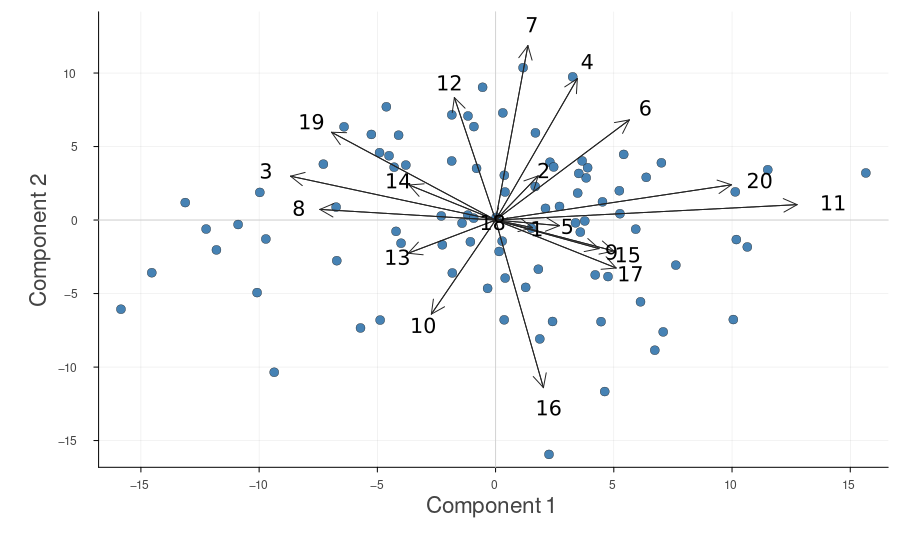

In [3]:
plot_biplot(S, m.loadings)

---

# Modifying the plot

The arguments that change **what we draw** are the same family as before — `group` and `comps` act on the points, `ntop` and `nonzero` on the arrows, `varnames` names them. The rest are styling: the arrow color and scale, the crosshairs, the class ellipses, and the standard `Plots` vocabulary.

## Grouping, naming, and thinning the arrows

`group` colors the observations by class and traces an ellipse around each one. `ntop` keeps only the variables with the largest absolute loading, which is what makes the arrow layer readable — eight is usually plenty. `varnames` labels those arrows; without it they are named by their index.

Read this figure as two layers at once: the classes separate left to right, and the arrows pointing that way name the variables responsible.

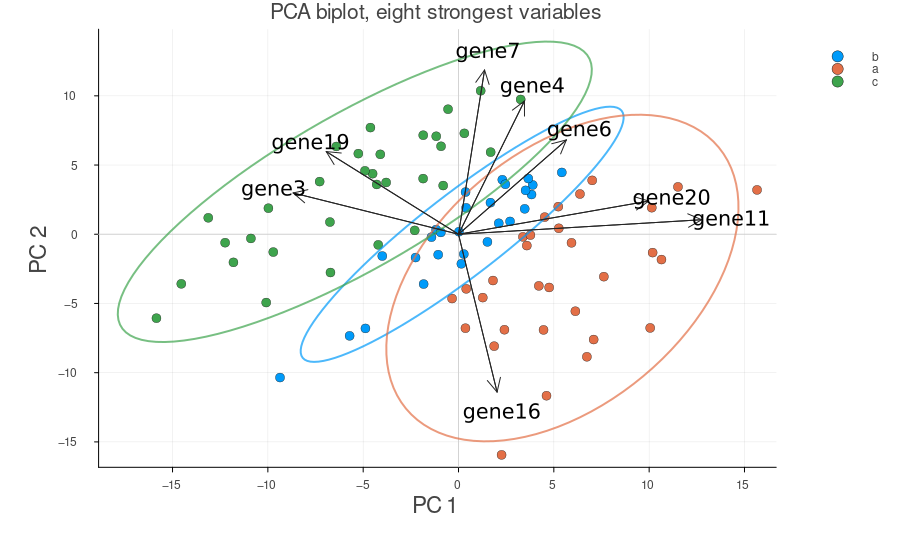

In [4]:
plot_biplot(S, m.loadings;
            group    = y,
            varnames = vnames,
            ntop     = 8,
            xlabel   = "PC 1",
            ylabel   = "PC 2",
            title    = "PCA biplot, eight strongest variables")

## Scaling the arrows

The scores and the loadings live on quite different scales, so the arrows have to be stretched to share a canvas with the points. `arrowscale` sets that stretch. It carries no statistical meaning — it is chosen so the arrows reach into the cloud without swamping it, and it needs adjusting whenever the data or the number of components changes.

Too small and the arrows huddle at the origin; too large and they run off the axes. Try both to see the range.

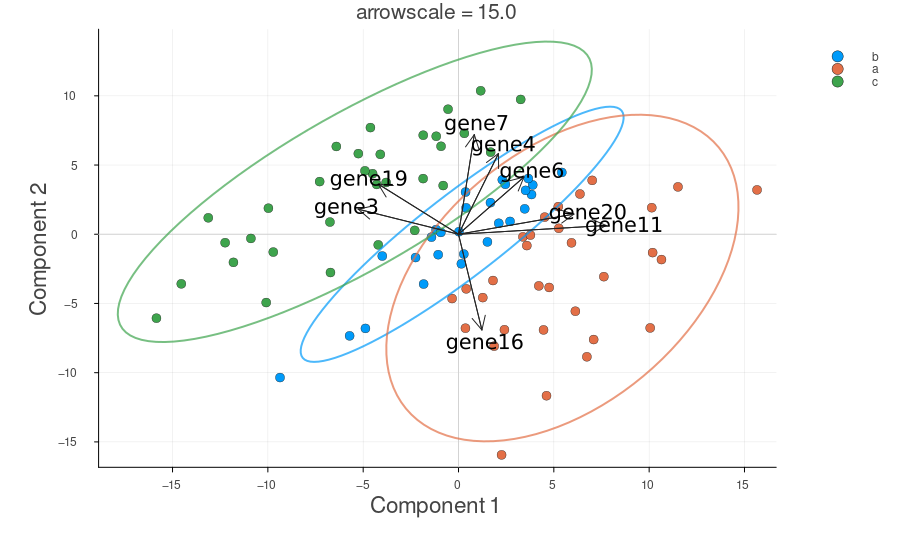

In [5]:
plot_biplot(S, m.loadings;
            group      = y,
            varnames   = vnames,
            ntop       = 8,
            arrowscale = 15.0,
            title      = "arrowscale = 15.0")

## Colors, ellipses, and the rest

`arrowcolor` sets the arrows, `origincolor` the crosshairs at zero. The class ellipses are drawn at `nstd` standard deviations and can be turned off with `ellipse = false` — worth doing when the classes overlap heavily and the rings obscure more than they show. A class of fewer than three observations gets no ellipse, since there is nothing to trace.

Everything the plot sets for itself yields to what we pass, so the standard attributes stack on top. The legend sits outside the axes by default, because the arrows reach into every corner where a legend would otherwise sit.

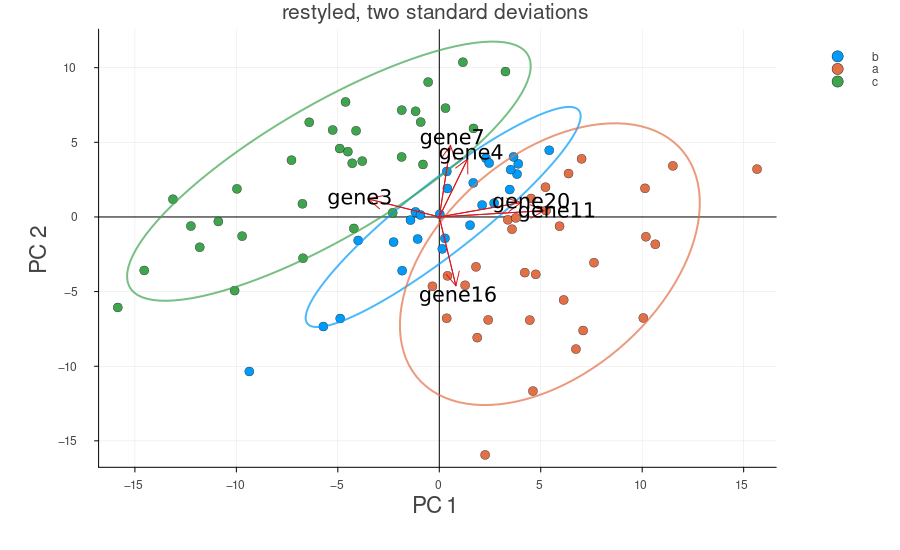

In [8]:
plot_biplot(S, m.loadings;
            group       = y,
            varnames    = vnames,
            ntop        = 6,
            arrowscale  = 10.0,
            arrowcolor  = "#d7191c",
            origincolor = :black,
            nstd        = 2.0,
            xlabel      = "PC 1",
            ylabel      = "PC 2",
            title       = "restyled, two standard deviations",
            marker      = 4,
            size        = (900, 550))